# 🚗 Vehicle Counter — HoG + SVM v3

**Cải tiến so với v2:**
| Kỹ thuật | Tác dụng |
|---|---|
| **OpenCV HOG** thay scikit-image | Nhanh hơn ~5x |
| **HOG Sub-sampling** | Tính HOG 1 lần cho cả ROI, không tính lại từng patch |
| **Multiprocessing Pool** | Chia pyramid levels cho nhiều CPU core |
| **Heatmap tích lũy** | Giảm False Positive, bỏ box chồng |
| **Detect thread riêng** | Webcam stream 30 FPS không chờ detect |
| **JPEG encode async** | Không block main loop |

## 📦 Bước 1 — Cài thư viện

In [17]:
#!pip install opencv-python scikit-learn scikit-image numpy flask joblib tqdm scipy

In [18]:
import os, cv2, joblib, numpy as np, time, threading, warnings
from scipy.ndimage import label as scipy_label
from skimage.feature import hog as sk_hog
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.calibration import CalibratedClassifierCV
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
warnings.filterwarnings('ignore')

print('✅ Import xong!')

✅ Import xong!


In [19]:
# ================================================================
#  CẤU HÌNH TOÀN CỤC
# ================================================================
IMG_SIZE   = (64, 64)     # OpenCV HOG dùng 64x64
WIN_SIZE   = (64, 64)
MODEL_PATH = 'vehicle_svm_v3.pkl'
POS_DIR    = 'data/positive/positive'
NEG_DIR    = 'data/negative/negative'
TEST_POS_DIR = 'data/test/positive'
TEST_NEG_DIR = 'data/test/negative'

# OpenCV HOGDescriptor — nhanh hơn scikit-image ~5x
HOG_CV = cv2.HOGDescriptor(
    _winSize   = (64, 64),
    _blockSize = (16, 16),
    _blockStride = (8, 8),
    _cellSize  = (8, 8),
    _nbins     = 9
)
HOG_FEATURE_LEN = int(HOG_CV.getDescriptorSize())   # = 1764

print(f'✅ Config xong! HOG feature size = {HOG_FEATURE_LEN}')

✅ Config xong! HOG feature size = 1764


## 🔬 Bước 2 — Trực quan hoá HoG (so sánh OpenCV vs scikit-image)

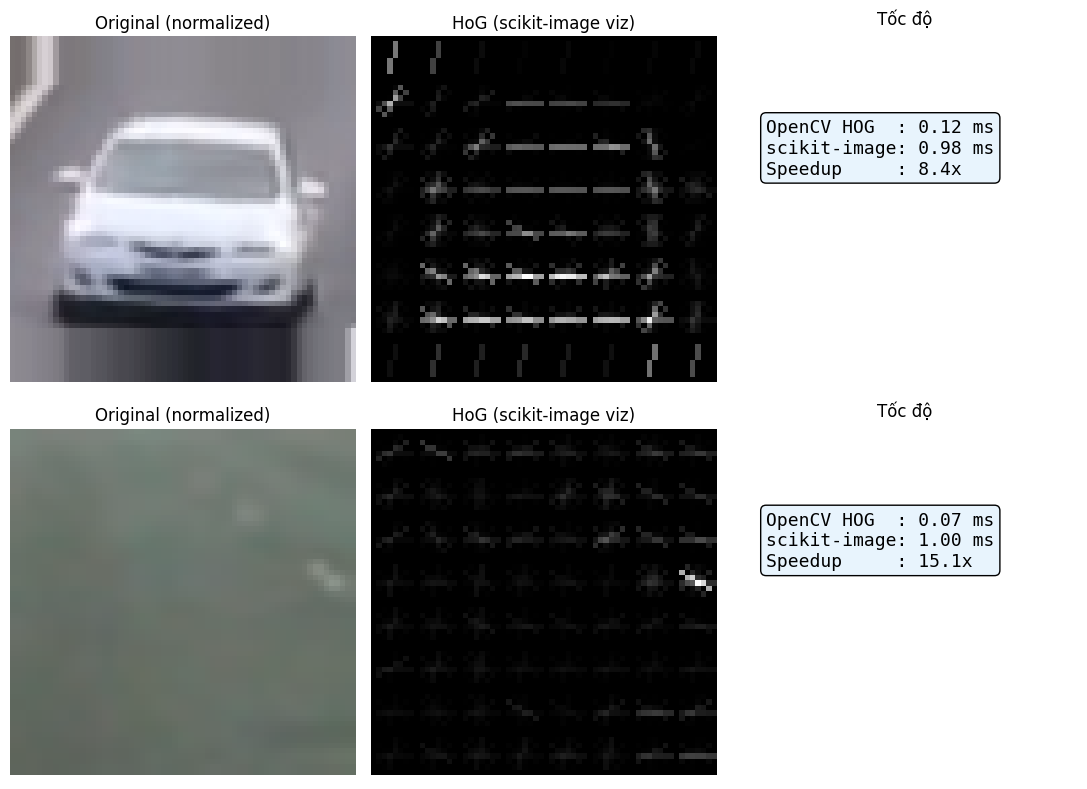

In [20]:
def resize_keep_aspect_with_padding(img, size=(64, 64)):
    """Resize giữ tỉ lệ + padding với border replicate để tránh artifacts."""
    target_w, target_h = size
    h, w = img.shape[:2]
    if h == 0 or w == 0:
        return np.zeros((target_h, target_w, 3), dtype=np.uint8)

    scale = min(target_w / w, target_h / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    # Dùng replicate border thay vì fill đơn giản để tránh đường gạch ở biên
    x0 = (target_w - new_w) // 2
    y0 = (target_h - new_h) // 2
    
    top = y0
    bottom = target_h - (y0 + new_h)
    left = x0
    right = target_w - (x0 + new_w)
    
    canvas = cv2.copyMakeBorder(resized, top, bottom, left, right,
                                cv2.BORDER_REPLICATE)
    return canvas


def extract_hog(img):
    """OpenCV HOG với resize giữ tỉ lệ + padding để giảm méo hình."""
    normalized = resize_keep_aspect_with_padding(img, IMG_SIZE)
    return HOG_CV.compute(normalized).flatten()


# ── Demo visualization ──────────────────────────────────────
sample_paths = []
for d in [POS_DIR, NEG_DIR]:
    if os.path.exists(d):
        files = [f for f in os.listdir(d) if f.lower().endswith(('.jpg','.png'))]
        if files:
            sample_paths.append(os.path.join(d, files[0]))

if sample_paths:
    fig, axes = plt.subplots(len(sample_paths), 3,
                             figsize=(11, 4*len(sample_paths)))
    if len(sample_paths) == 1:
        axes = [axes]
    for ax_row, path in zip(axes, sample_paths):
        img = cv2.imread(path)
        rgb = cv2.cvtColor(resize_keep_aspect_with_padding(img, IMG_SIZE), cv2.COLOR_BGR2RGB)

        # scikit-image HoG visualization
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        _, hog_img = sk_hog(gray, orientations=9, pixels_per_cell=(8,8),
                             cells_per_block=(2,2), visualize=True,
                             transform_sqrt=True)

        # OpenCV HOG speed test
        t0 = time.time()
        for _ in range(200):
            extract_hog(img)
        t_cv = (time.time()-t0)/200*1000

        t0 = time.time()
        for _ in range(200):
            sk_hog(gray, orientations=9, pixels_per_cell=(8,8),
                   cells_per_block=(2,2), transform_sqrt=True)
        t_sk = (time.time()-t0)/200*1000

        ax_row[0].imshow(rgb);          ax_row[0].set_title('Original (normalized)');   ax_row[0].axis('off')
        ax_row[1].imshow(hog_img, cmap='gray'); ax_row[1].set_title('HoG (scikit-image viz)'); ax_row[1].axis('off')
        ax_row[2].axis('off')
        ax_row[2].text(0.1, 0.6,
            f'OpenCV HOG  : {t_cv:.2f} ms\n'
            f'scikit-image: {t_sk:.2f} ms\n'
            f'Speedup     : {t_sk/t_cv:.1f}x',
            transform=ax_row[2].transAxes,
            fontsize=13, fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#e8f4fd'))
        ax_row[2].set_title('Tốc độ')

    plt.tight_layout(); plt.show()
else:
    print('⚠️  Chưa có data — đặt ảnh vào POS_DIR / NEG_DIR')

## 🧠 Bước 3 — Huấn luyện LinearSVM

In [21]:
print('📂 Bước 1: Load path + label...')

all_paths, all_labels = [], []
for label, directory in [(1, POS_DIR), (0, NEG_DIR)]:
    if not os.path.exists(directory):
        print(f'⚠️  Không tìm thấy: {directory}'); continue
    files = [f for f in os.listdir(directory)
             if f.lower().endswith(('.jpg','.png','.jpeg'))]
    tag = 'vehicles' if label else 'non_vehicles'
    for fname in tqdm(files, desc=f'Load path {tag}'):
        all_paths.append(os.path.join(directory, fname))
        all_labels.append(label)

all_labels = np.array(all_labels)
print(f'✅ Tổng ảnh gốc: {len(all_paths)}')
print(f'   Xe     : {all_labels.sum()}')
print(f'   Non-xe : {(all_labels==0).sum()}')

📂 Bước 1: Load path + label...


Load path non_vehicles: 100%|██████████| 7167/7167 [00:00<00:00, 465528.58it/s]

✅ Tổng ảnh gốc: 10424
   Xe     : 3257
   Non-xe : 7167


In [22]:
print('📂 Bước 2: Load test set từ folder riêng...')

paths_train    = all_paths       # toàn bộ data chung là train
y_train_labels = all_labels

paths_test, y_test_labels_list = [], []
for label, directory in [(1, TEST_POS_DIR), (0, TEST_NEG_DIR)]:
    if not os.path.exists(directory):
        print(f'⚠️  Không tìm thấy: {directory}'); continue
    files = [f for f in os.listdir(directory)
             if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    tag = 'test_vehicles' if label else 'test_non_vehicles'
    for fname in tqdm(files, desc=f'Load path {tag}'):
        paths_test.append(os.path.join(directory, fname))
        y_test_labels_list.append(label)

y_test_labels = np.array(y_test_labels_list)
print(f'✅ Train : {len(paths_train)} ảnh')
print(f'   Test  : {len(paths_test)} ảnh — từ folder riêng')

📂 Bước 2: Load test set từ folder riêng...


Load path test_non_vehicles: 100%|██████████| 409/409 [00:00<?, ?it/s]

✅ Train : 10424 ảnh
   Test  : 922 ảnh — từ folder riêng


In [23]:
print('🔒 Bước 3: Trích HOG tập test (không augment)...')

X_test, y_test = [], []
for path, label in tqdm(zip(paths_test, y_test_labels), total=len(paths_test), desc='HOG test'):
    img = cv2.imread(path)
    if img is None: continue
    X_test.append(extract_hog(img))
    y_test.append(label)
    del img

X_test = np.array(X_test)
y_test = np.array(y_test)
print(f'✅ Test set: {len(X_test)} mẫu | shape: {X_test.shape}')

🔒 Bước 3: Trích HOG tập test (không augment)...


HOG test: 100%|██████████| 922/922 [00:09<00:00, 100.35it/s]

✅ Test set: 922 mẫu | shape: (922, 1764)


In [24]:
print('🔄 Bước 4: Trích HOG ảnh gốc tập train (chưa augment)...')

X_orig, y_orig = [], []
valid_paths = []   # lưu lại path hợp lệ để augment_fold dùng

for path, label in tqdm(zip(paths_train, y_train_labels),
                        total=len(paths_train), desc='HOG gốc'):
    img = cv2.imread(path)
    if img is None:
        continue
    X_orig.append(extract_hog(img))
    y_orig.append(label)
    valid_paths.append(path)
    del img

X_orig = np.array(X_orig)
y_orig = np.array(y_orig)
print(f'✅ Ảnh gốc: {len(X_orig)} mẫu | shape: {X_orig.shape}')

🔄 Bước 4: Trích HOG ảnh gốc tập train (chưa augment)...


HOG gốc: 100%|██████████| 10424/10424 [01:40<00:00, 103.37it/s]

✅ Ảnh gốc: 10424 mẫu | shape: (10424, 1764)


In [25]:
def augment_fold(indices):
    """Augment CHỈ các ảnh trong indices, trả về X và y đã augment."""
    X_aug, y_aug = [], []
    for i in indices:
        img = cv2.imread(valid_paths[i])
        if img is None:
            continue
        candidates = [
            img,
            cv2.flip(img, 1),
            cv2.convertScaleAbs(img, alpha=1.08, beta=12),
            cv2.convertScaleAbs(img, alpha=0.92, beta=-12),
        ]
        if y_orig[i] == 1:
            candidates.append(cv2.GaussianBlur(img, (3, 3), 0))
        for aug in candidates:
            X_aug.append(extract_hog(aug))
            y_aug.append(y_orig[i])
        del img, candidates
    return np.array(X_aug), np.array(y_aug)

print('✅ Hàm augment_fold ready!')

✅ Hàm augment_fold ready!


In [26]:
from sklearn.model_selection import StratifiedKFold

print('🔍 Bước 5: GridSearch với augment đúng trong từng fold...')

C_grid = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

best_C, best_score = 0.01, -1.0
results = []

for C in C_grid:
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_orig, y_orig)):
        # Augment CHỈ fold train
        X_tr, y_tr = augment_fold(train_idx)
        # Val dùng ảnh gốc, không augment
        X_val = X_orig[val_idx]
        y_val = y_orig[val_idx]

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', CalibratedClassifierCV(
                LinearSVC(C=C, max_iter=5000, class_weight='balanced'),
                cv=3
            ))
        ])
        pipe.fit(X_tr, y_tr)
        score = f1_score(y_val, pipe.predict(X_val), zero_division=0)
        fold_scores.append(score)

    mean_f1 = np.mean(fold_scores)
    results.append((C, mean_f1))
    print(f'  C={C:.3f}  →  F1 CV = {mean_f1:.4f}')
    if mean_f1 > best_score:
        best_score, best_C = mean_f1, C

print(f'\n✅ C tốt nhất : {best_C}')
print(f'   F1 CV sạch : {best_score:.4f}')

# Train final model trên TOÀN BỘ train có augment với C tốt nhất
print('\n🔄 Train model cuối trên toàn bộ tập train (có augment)...')
X_train_full, y_train_full = augment_fold(np.arange(len(X_orig)))

model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', CalibratedClassifierCV(
        LinearSVC(C=best_C, max_iter=5000, class_weight='balanced'),
        cv=3
    ))
])
model.fit(X_train_full, y_train_full)

# Đánh giá trên test set
y_pred = model.predict(X_test)
print('\n📊 Kết quả trên test set (threshold = 0.50):')
print(classification_report(y_test, y_pred, target_names=['non_vehicle', 'vehicle']))

joblib.dump(model, MODEL_PATH)
print(f'💾 Đã lưu → {MODEL_PATH}')

🔍 Bước 5: GridSearch với augment đúng trong từng fold...
  C=0.001  →  F1 CV = 0.9968
  C=0.005  →  F1 CV = 0.9966
  C=0.010  →  F1 CV = 0.9965
  C=0.050  →  F1 CV = 0.9972
  C=0.100  →  F1 CV = 0.9971
  C=0.500  →  F1 CV = 0.9971
  C=1.000  →  F1 CV = 0.9971

✅ C tốt nhất : 0.05
   F1 CV sạch : 0.9972

🔄 Train model cuối trên toàn bộ tập train (có augment)...

📊 Kết quả trên test set (threshold = 0.50):
              precision    recall  f1-score   support

 non_vehicle       0.98      1.00      0.99       409
     vehicle       1.00      0.98      0.99       513

    accuracy                           0.99       922
   macro avg       0.99      0.99      0.99       922
weighted avg       0.99      0.99      0.99       922

💾 Đã lưu → vehicle_svm_v3.pkl


In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, roc_curve, auc,
                             precision_recall_curve, average_precision_score)

# ── Dự đoán ──────────────────────────────────────────────────
y_pred2 = model.predict(X_test)
probs2  = model.predict_proba(X_test)[:, 1]

# ── 1. Classification Report ─────────────────────────────────
print('📊 Classification Report trước Hard Negative Mining:')
print(classification_report(y_test, y_pred2, target_names=['non_vehicle', 'vehicle']))

# ── 2. Các chỉ số tổng hợp ───────────────────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('📌 Tóm tắt chỉ số:')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred2):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred2):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred2):.4f}')
print(f'  F1 Score  : {f1_score(y_test, y_pred2):.4f}')
print(f'  AUC-ROC   : {auc(*roc_curve(y_test, probs2)[:2]):.4f}')

# ── 3. Vẽ tất cả biểu đồ ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Đánh giá mô hình trước Hard Negative Mining', 
             fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred2)
ConfusionMatrixDisplay(cm, display_labels=['Non-xe', 'Xe']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')

# Thêm số liệu TP/TN/FP/FN vào tiêu đề phụ
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(
    f'TN={tn}  FP={fp}  FN={fn}  TP={tp}', fontsize=10)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, probs2)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#2E75B6', lw=2,
             label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2E75B6')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# Precision-Recall Curve
precision_arr, recall_arr, _ = precision_recall_curve(y_test, probs2)
ap = average_precision_score(y_test, probs2)
axes[2].plot(recall_arr, precision_arr, color='#f97316', lw=2,
             label=f'AP = {ap:.4f}')
axes[2].fill_between(recall_arr, precision_arr, alpha=0.1, color='#f97316')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].legend(loc='upper right')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_before_hnm.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Đã lưu → evaluation_before_hnm.png')

## 🔧 Bước 4 — Hard Negative Mining

In [27]:
def hard_negative_mining(model, neg_dir, step=32, win=(64,64),
                         threshold=0.5, max_per_img=15, max_total=2000):
    hard_negs = []
    files = [f for f in os.listdir(neg_dir)
             if f.lower().endswith(('.jpg','.png','.jpeg'))]
    for fname in tqdm(files, desc='Hard Negative Mining'):
        if len(hard_negs) >= max_total: break
        img = cv2.imread(os.path.join(neg_dir, fname))
        if img is None: continue
        count = 0
        for yy in range(0, img.shape[0]-win[1], step):
            for xx in range(0, img.shape[1]-win[0], step):
                if count >= max_per_img: break
                patch = img[yy:yy+win[1], xx:xx+win[0]]
                if patch.shape[:2] != (win[1], win[0]): continue
                prob = model.predict_proba(extract_hog(patch).reshape(1,-1))[0][1]
                if prob >= threshold:
                    hard_negs.append(extract_hog(patch))
                    count += 1
    print(f'\n✅ Thu thập {len(hard_negs)} hard negatives')
    return np.array(hard_negs) if hard_negs else None

if len(X_train_full) > 0 and os.path.exists(NEG_DIR):
    model = joblib.load(MODEL_PATH)
    hard_negs = hard_negative_mining(model, NEG_DIR)
    
    if hard_negs is not None:
        # Gộp hard negative vào tập train đầy đủ
        X_aug = np.vstack([X_train_full, hard_negs])
        y_aug = np.hstack([y_train_full, np.zeros(len(hard_negs), dtype=int)])
        perm  = np.random.permutation(len(X_aug))
        X_aug, y_aug = X_aug[perm], y_aug[perm]

        # Train lại ĐÚNG CÁCH: GridSearch + Calibration với C tốt nhất cũ
        print(f'\n🔄 Train lại với hard negatives (C={best_C})...')
        model_hnm = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', CalibratedClassifierCV(
                LinearSVC(C=best_C, max_iter=5000, class_weight='balanced'),
                cv=3
            ))
        ])
        model_hnm.fit(X_aug, y_aug)

        y_pred2 = model_hnm.predict(X_test)
        print('\n📊 Sau Hard Negative Mining:')
        print(classification_report(y_test, y_pred2,
                                    target_names=['non_vehicle', 'vehicle']))

        joblib.dump(model_hnm, MODEL_PATH)
        model = model_hnm   # cập nhật model đang dùng
        print(f'💾 Model updated → {MODEL_PATH}')

Hard Negative Mining:  83%|████████▎ | 5931/7167 [09:50<02:03, 10.04it/s]  


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, roc_curve, auc,
                             precision_recall_curve, average_precision_score)

# ── Dự đoán ──────────────────────────────────────────────────
y_pred2 = model.predict(X_test)
probs2  = model.predict_proba(X_test)[:, 1]

# ── 1. Classification Report ─────────────────────────────────
print('📊 Classification Report sau Hard Negative Mining:')
print(classification_report(y_test, y_pred2, target_names=['non_vehicle', 'vehicle']))

# ── 2. Các chỉ số tổng hợp ───────────────────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('📌 Tóm tắt chỉ số:')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred2):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred2):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred2):.4f}')
print(f'  F1 Score  : {f1_score(y_test, y_pred2):.4f}')
print(f'  AUC-ROC   : {auc(*roc_curve(y_test, probs2)[:2]):.4f}')

# ── 3. Vẽ tất cả biểu đồ ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Đánh giá mô hình sau Hard Negative Mining', 
             fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred2)
ConfusionMatrixDisplay(cm, display_labels=['Non-xe', 'Xe']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')

# Thêm số liệu TP/TN/FP/FN vào tiêu đề phụ
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(
    f'TN={tn}  FP={fp}  FN={fn}  TP={tp}', fontsize=10)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, probs2)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#2E75B6', lw=2,
             label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2E75B6')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# Precision-Recall Curve
precision_arr, recall_arr, _ = precision_recall_curve(y_test, probs2)
ap = average_precision_score(y_test, probs2)
axes[2].plot(recall_arr, precision_arr, color='#f97316', lw=2,
             label=f'AP = {ap:.4f}')
axes[2].fill_between(recall_arr, precision_arr, alpha=0.1, color='#f97316')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].legend(loc='upper right')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_after_hnm.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Đã lưu → evaluation_after_hnm.png')

## 🎯 Bước 5 — Detector: HOG Sub-sampling + Heatmap

**HOG Sub-sampling** = tính HOG **1 lần** cho toàn ROI → cắt feature vector từng window.
Nhanh hơn cách cũ (tính HOG từng patch) **~3–5x**.

**Heatmap** = tích lũy detection qua nhiều frame → loại FP tự động.

In [ ]:
# ── NMS ─────────────────────────────────────────────────────
def nms(boxes, scores, iou_thresh=0.4):
    if not boxes: return []
    b = np.array(boxes, dtype=np.float32)
    s = np.array(scores)
    x1,y1,x2,y2 = b[:,0],b[:,1],b[:,2],b[:,3]
    areas = (x2-x1+1)*(y2-y1+1)
    order = s.argsort()[::-1]; keep = []
    while order.size:
        i = order[0]; keep.append(i)
        xx1=np.maximum(x1[i],x1[order[1:]]); yy1=np.maximum(y1[i],y1[order[1:]])
        xx2=np.minimum(x2[i],x2[order[1:]]); yy2=np.minimum(y2[i],y2[order[1:]])
        inter=np.maximum(0,xx2-xx1+1)*np.maximum(0,yy2-yy1+1)
        iou=inter/(areas[i]+areas[order[1:]]-inter)
        order=order[np.where(iou<=iou_thresh)[0]+1]
    return keep


# ── HOG SUB-SAMPLING DETECT ──────────────────────────────────
def detect_subsample(frame, model, scaler,
                     threshold=0.6,
                     win=(64,64), cell=8, block=2,
                     step_cells=2,          # bước trượt tính bằng số cell
                     scales=(1.0, 1.5, 2.0),
                     roi_top=0.35, roi_bottom=0.85):
    """
    HOG Sub-sampling: tính HOG 1 lần cho ROI, trượt trên feature map.
    Nhanh hơn tính từng patch ~3-5x.
    """
    H, W = frame.shape[:2]
    y1o, y2o = int(H*roi_top), int(H*roi_bottom)
    roi = frame[y1o:y2o]

    all_boxes, all_scores = [], []

    for scale in scales:
        # Scale ROI
        rh, rw = roi.shape[:2]
        new_w, new_h = int(rw/scale), int(rh/scale)
        if new_w < win[0] or new_h < win[1]:
            continue
        scaled_roi = cv2.resize(roi, (new_w, new_h))
        gray_roi   = cv2.cvtColor(scaled_roi, cv2.COLOR_BGR2GRAY)

        # Tính HOG cho toàn ROI scaled
        # cells_per_roi
        n_cells_y = gray_roi.shape[0] // cell
        n_cells_x = gray_roi.shape[1] // cell
        cells_per_win = win[0] // cell   # = 8 cells (cho 64px win, cell=8)

        # Trượt cửa sổ trên feature space
        for fy in range(0, n_cells_y - cells_per_win, step_cells):
            for fx in range(0, n_cells_x - cells_per_win, step_cells):
                # Lấy patch từ scaled ROI
                px = fx * cell
                py = fy * cell
                patch = scaled_roi[py:py+win[1], px:px+win[0]]
                if patch.shape[:2] != (win[1], win[0]):
                    continue

                # HOG của patch (dùng OpenCV)
                feat = HOG_CV.compute(patch).flatten().reshape(1,-1)
                feat_scaled = scaler.transform(feat)

                # predict_proba
                prob = model.predict_proba(feat_scaled)[0][1]
                if prob >= threshold:
                    # Map về tọa độ frame gốc
                    bx1 = int(px * scale)
                    by1 = int(py * scale) + y1o
                    bx2 = int((px+win[0]) * scale)
                    by2 = int((py+win[1]) * scale) + y1o
                    all_boxes.append([bx1, by1, bx2, by2])
                    all_scores.append(prob)

    keep = nms(all_boxes, all_scores, iou_thresh=0.45)
    #keep = nms(all_boxes, all_scores, thr=0.45)

    return [all_boxes[i] for i in keep], [all_scores[i] for i in keep]


# ── HEATMAP ──────────────────────────────────────────────────
class Heatmap:
    """
    Tích lũy detection qua nhiều frame → loại False Positive.
    decay : frame cũ mờ dần (0.8 = giữ 80% nhiệt độ frame trước)
    threshold : vùng phải được detect >= threshold lần mới tính là xe
    """
    def __init__(self, shape, decay=0.82, threshold=2.5):
        self.map       = np.zeros(shape[:2], dtype=np.float32)
        self.decay     = decay
        self.threshold = threshold

    def update(self, boxes):
        self.map *= self.decay
        for b in boxes:
            self.map[b[1]:b[3], b[0]:b[2]] += 1.5

    def get_boxes(self):
        binary = (self.map >= self.threshold).astype(np.uint8)
        labeled, n = scipy_label(binary)
        boxes = []
        for car_num in range(1, n+1):
            nz = (labeled == car_num).nonzero()
            if len(nz[0]) < 200:   # bỏ blob quá nhỏ
                continue
            y1,y2 = int(np.min(nz[0])), int(np.max(nz[0]))
            x1,x2 = int(np.min(nz[1])), int(np.max(nz[1]))
            boxes.append((x1,y1,x2,y2))
        return boxes

    def visualize(self, frame):
        """Vẽ heatmap overlay lên frame."""
        h_norm = np.clip(self.map / max(self.map.max(), 1), 0, 1)
        h_color = cv2.applyColorMap((h_norm*255).astype(np.uint8),
                                     cv2.COLORMAP_JET)
        return cv2.addWeighted(frame, 0.7, h_color, 0.3, 0)




print('✅ Detector + Heatmap ready!')

✅ Detector + Heatmap ready!


In [ ]:
# ── DETECTION QUEUE (thay thế Heatmap decay) ─────────────────
import queue as queue_module

class DetectionQueue:
    """
    Thay Heatmap decay bằng Queue N frame.
    - Heatmap decay: map *= 0.82 → mờ dần → box mất sớm
    - DetectionQueue: giữ nguyên N frame gần nhất → box ổn định hơn
    
    Xe phải xuất hiện trong ít nhất HEAT_THRESH / N frame
    mới được vẽ box → loại FP tốt hơn.
    """
    def __init__(self, shape, max_size=8, heat_thresh=6, min_area=200):
        self.shape      = shape[:2]
        self.max_size   = max_size      # giữ N frame gần nhất
        self.heat_thresh= heat_thresh   # xuất hiện >= thresh lần mới tính là xe
        self.min_area   = min_area
        self.queue      = queue_module.Queue(max_size)

    def update(self, boxes):
        """Thêm boxes frame mới, tự xóa frame cũ nhất khi đầy."""
        if self.queue.qsize() == self.max_size:
            self.queue.get()            # xóa frame cũ nhất
        self.queue.put(boxes)           # thêm frame mới

    def get_heatmap(self):
        """Cộng dồn tất cả frame trong queue thành heatmap."""
        heatmap = np.zeros(self.shape, dtype=np.float32)
        for boxes in list(self.queue.queue):
            for b in boxes:
                heatmap[b[1]:b[3], b[0]:b[2]] += 1
        heatmap[heatmap <= self.heat_thresh] = 0
        return heatmap

    def get_boxes(self):
        """Trả về bounding boxes sau threshold + label."""
        heatmap = self.get_heatmap()
        binary  = (heatmap > 0).astype(np.uint8)
        labeled, n = scipy_label(binary)
        boxes = []
        for k in range(1, n+1):
            nz = (labeled == k).nonzero()
            if len(nz[0]) < self.min_area:
                continue
            y1, y2 = int(nz[0].min()), int(nz[0].max())
            x1, x2 = int(nz[1].min()), int(nz[1].max())
            boxes.append((x1, y1, x2, y2))
        return boxes

print('✅ DetectionQueue ready!')

✅ DetectionQueue ready!


## 🎬 Bước 6 — Test trên VIDEO FILE

In [ ]:
# ── CHỌN PRESET ──────────────────────────────────────────────
PRESET_WEB = {
    'THRESHOLD'   : 0.4,
    'SCALES'      : (0.8, 1.0, 1.5),
    'STEP_CELLS'  : 3,
    'ROI_TOP'     : 0.40,
    'ROI_BOTTOM'  : 0.90,
    'CAP_W'       : 480,
    'CAP_H'       : 360,
    'JPEG_Q'      : 75,
    'DETECT_EVERY': 1,
    'HEAT_DECAY'  : 0.85,
    'HEAT_THRESH' : 2.0,
    'QUEUE_SIZE'  : 6,
    'QUEUE_THRESH': 4,
}
PRESET_VIDEO = {
    'THRESHOLD'   : 0.40,               # thấp hơn → bắt nhiều xe hơn
    'SCALES'      : ( 0.8, 1.0, 1.5),  # nhiều scale hơn
    'STEP_CELLS'  : 2,                  # bước nhỏ nhất
    'ROI_TOP'     : 0.35,               # mở rộng vùng detect
    'ROI_BOTTOM'  : 0.95,
    'CAP_W'       : 480,
    'CAP_H'       : 360,
    'JPEG_Q'      : 85,
    'DETECT_EVERY': 2,                  # detect mỗi frame
    'HEAT_DECAY'  : 0.85,
    'HEAT_THRESH' : 2.0,
    'QUEUE_SIZE'  : 12,                 # queue dài hơn → box ổn định hơn
    'QUEUE_THRESH': 7,
}
# 👇 ĐỔI PRESET TẠI ĐÂY
SELECTED = PRESET_WEB

print('✅ Preset:', SELECTED)

✅ Preset: {'THRESHOLD': 0.4, 'SCALES': (0.8, 1.0, 1.5), 'STEP_CELLS': 3, 'ROI_TOP': 0.4, 'ROI_BOTTOM': 0.9, 'CAP_W': 480, 'CAP_H': 360, 'JPEG_Q': 75, 'DETECT_EVERY': 1, 'HEAT_DECAY': 0.85, 'HEAT_THRESH': 2.0, 'QUEUE_SIZE': 6, 'QUEUE_THRESH': 4}


In [ ]:
VIDEO_PATH  = 'test_video.mp4'   # ← đổi thành file video của bạn
OUTPUT_PATH = 'output_v3.mp4'
_cfg = PRESET_VIDEO   # ← dùng preset video riêng

# ── Detector params ──────────────────────────────────────────
DET_THRESHOLD  = float(globals().get('BEST_THRESHOLD', 0.4))
DET_SCALES     = _cfg['SCALES']
DET_STEP_CELLS = _cfg['STEP_CELLS']
ROI_TOP        = _cfg['ROI_TOP']
ROI_BOTTOM     = _cfg['ROI_BOTTOM']
FRAME_SKIP     = 2
QUEUE_SIZE     = _cfg['QUEUE_SIZE']
QUEUE_THRESH   = _cfg['QUEUE_THRESH']
HEAT_DECAY     = 0.82   # giữ lại cho Heatmap cũ (không dùng nữa)
HEAT_THRESHOLD = 2.5    # giữ lại cho Heatmap cũ (không dùng nữa)
LINE_RATIO     = 0.65
SHOW_HEATMAP   = False              # True → overlay heatmap màu

# Load model
model_full = joblib.load(MODEL_PATH)
scaler     = model_full.named_steps['scaler']
clf_only   = model_full.named_steps['clf']
print(f'✅ Model loaded! DET_THRESHOLD={DET_THRESHOLD:.2f}')

✅ Model loaded! DET_THRESHOLD=0.40


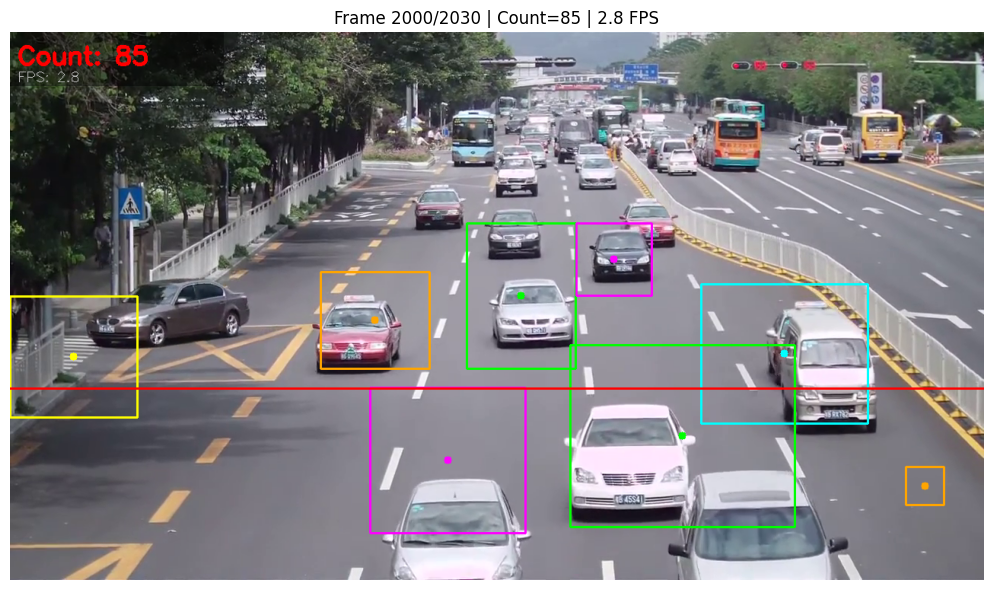

100%|██████████| 2030/2030 [11:58<00:00,  2.83frame/s]


✅ Xong! Xe: 86 | 2.8 FPS | output_v3.mp4


In [ ]:
def run_on_video(video_path, output_path):
    if not os.path.exists(video_path):
        print(f'❌ Không tìm thấy: {video_path}'); return

    cap   = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)  # ✅ thêm: giảm buffer lag
    W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps_v = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f'📹 {W}x{H} @ {fps_v:.0f}fps | {total} frames')

    # ✅ Resize frame nhỏ lại trước khi detect nếu quá lớn
    DETECT_W = W
    DETECT_SCALE = 1 # tỉ lệ để map box về kích thước gốc

    writer        = cv2.VideoWriter(output_path,
                        cv2.VideoWriter_fourcc(*'mp4v'), fps_v, (W, H))
    heat          = DetectionQueue((H, W), max_size=QUEUE_SIZE, heat_thresh=QUEUE_THRESH)
    LINE_Y        = int(H * LINE_RATIO)
    vehicle_count = 0
    prev_centers  = []
    final_boxes   = []
    frame_idx     = 0
    t_start       = time.time()
    COLORS        = [(0,255,0),(255,0,255),(0,165,255),(255,255,0),(0,255,255)]

    # ✅ Chuẩn bị enc_params JPEG để write nhanh hơn
    enc_params = [cv2.IMWRITE_JPEG_QUALITY, 85]

    # ✅ Batch predict: gom tất cả patch 1 frame → predict 1 lần
    def detect_batch(frame_small):
        H_s, W_s = frame_small.shape[:2]
        y1o, y2o = int(H_s * ROI_TOP), int(H_s * ROI_BOTTOM)
        roi = frame_small[y1o:y2o]
        all_feats, all_coords = [], []

        for scale in DET_SCALES:
            rh, rw = roi.shape[:2]
            nw, nh = int(rw / scale), int(rh / scale)
            if nw < 64 or nh < 64: continue
            sroi = cv2.resize(roi, (nw, nh))
            ncx, ncy = nw // 8, nh // 8

            for fy in range(0, ncy - 8, DET_STEP_CELLS):
                for fx in range(0, ncx - 8, DET_STEP_CELLS):
                    px, py = fx * 8, fy * 8
                    patch = sroi[py:py+64, px:px+64]
                    if patch.shape[:2] != (64, 64): continue
                    all_feats.append(HOG_CV.compute(patch).flatten())
                    all_coords.append((px, py, scale, y1o))

        if not all_feats:
            return []

        # ✅ Batch transform + predict 1 lần thay vì từng patch
        feats_arr  = np.array(all_feats)
        feats_sc   = scaler.transform(feats_arr)
        probs_batch = clf_only.predict_proba(feats_sc)[:, 1]

        boxes, scores = [], []
        for i, (px, py, scale, y1o) in enumerate(all_coords):
            if probs_batch[i] >= DET_THRESHOLD:
                # Map về kích thước frame gốc
                inv = 1.0 / DETECT_SCALE
                bx1 = int(px * scale * inv)
                by1 = int(py * scale * inv) + int(y1o * inv)
                bx2 = int((px+64) * scale * inv)
                by2 = int((py+64) * scale * inv) + int(y1o * inv)
                boxes.append([bx1, by1, bx2, by2])
                scores.append(probs_batch[i])

        keep = nms(boxes, scores, iou_thresh=0.45)
        return [boxes[i] for i in keep]

    pbar = tqdm(total=total, unit='frame')
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        if frame_idx % FRAME_SKIP == 0:
            # ✅ Resize nhỏ để detect nhanh hơn
            frame_small = cv2.resize(frame, (DETECT_W, int(H * DETECT_SCALE)))
            raw_boxes   = detect_batch(frame_small)
            heat.update(raw_boxes)
            final_boxes = heat.get_boxes()

            # Đếm crossing
            curr_c = [((b[0]+b[2])//2, (b[1]+b[3])//2) for b in final_boxes]
            for cx, cy in curr_c:
                matched_prev_y = None
                min_dist = float('inf')
                for px, py in prev_centers:
                    dist = ((cx-px)**2 + (cy-py)**2)**0.5
                    max_dist = max(100, H * 0.12)
                    if dist < max_dist and dist < min_dist:
                        min_dist = dist
                        matched_prev_y = py
                if matched_prev_y is not None and matched_prev_y < LINE_Y and cy >= LINE_Y:
                    vehicle_count += 1
            prev_centers = curr_c

        # Vẽ
        for i, (x1,y1,x2,y2) in enumerate(final_boxes):
            col = COLORS[i % len(COLORS)]
            cv2.rectangle(frame, (x1,y1), (x2,y2), col, 2)
            cv2.circle(frame, ((x1+x2)//2, (y1+y2)//2), 5, col, -1)

        cv2.line(frame, (0,LINE_Y), (W,LINE_Y), (0,0,255), 2)

        elapsed  = time.time() - t_start
        live_fps = (frame_idx+1) / elapsed if elapsed > 0 else 0
        overlay  = frame.copy()
        cv2.rectangle(overlay, (0,0), (280,70), (0,0,0), -1)
        cv2.addWeighted(overlay, 0.45, frame, 0.55, 0, frame)
        cv2.putText(frame, f'Count: {vehicle_count}',
                    (10,42), cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0,0,255), 3)
        cv2.putText(frame, f'FPS: {live_fps:.1f}',
                    (10,65), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200,200,200), 1)

        writer.write(frame)
        frame_idx += 1
        pbar.update(1)

        # ✅ Preview thưa hơn — mỗi 60 frame thay vì 40
        if frame_idx % 40 == 0:
            from IPython.display import clear_output
            clear_output(wait=True)
            plt.figure(figsize=(12,6))
            plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            plt.title(f'Frame {frame_idx}/{total} | Count={vehicle_count} | {live_fps:.1f} FPS')
            plt.axis('off'); plt.tight_layout(); plt.show()

    pbar.close(); cap.release(); writer.release()
    tt = time.time() - t_start
    print(f'\n✅ Xong! Xe: {vehicle_count} | {frame_idx/tt:.1f} FPS | {output_path}')

run_on_video(VIDEO_PATH, OUTPUT_PATH)

📸 Ảnh: 1315x667 | test.png


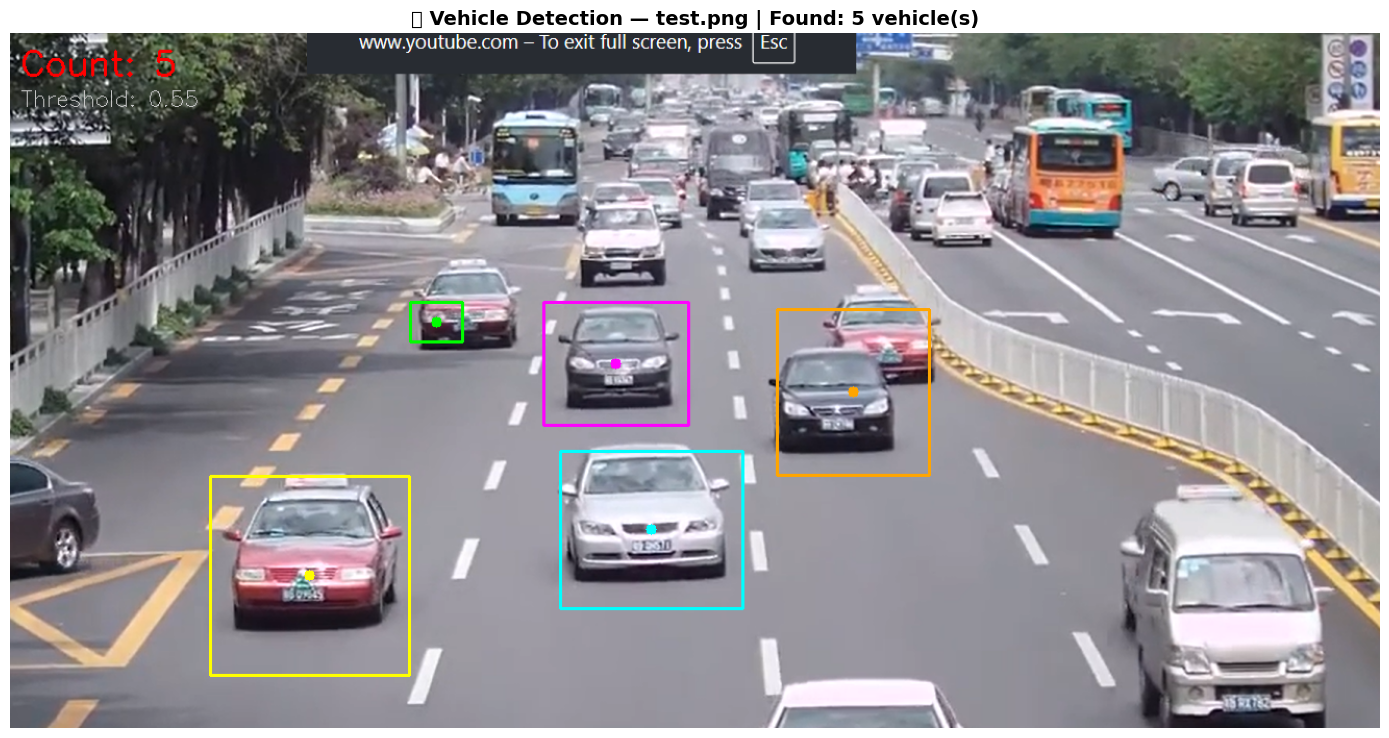


📊 Kết quả:
  ✓ Tổng xe phát hiện: 5
  ✓ Threshold: 0.55
  ✓ Boxes:
    Box 1: (384, 258) → (434, 296) | Size: 50x38
    Box 2: (512, 258) → (651, 376) | Size: 139x118
    Box 3: (736, 265) → (882, 424) | Size: 146x159
    Box 4: (528, 401) → (703, 552) | Size: 175x151
    Box 5: (192, 425) → (383, 616) | Size: 191x191


In [ ]:
def test_image(image_path, threshold=0.5, scales=(0.8, 1.0, 1.5, 2.0)):
    """
    Test một ảnh bên ngoài dataset.
    
    Params:
        image_path: Đường dẫn ảnh
        threshold: Confidence threshold (mặc định 0.58)
        scales: Multi-scale detection (mặc định (1.0, 1.5, 2.0))
    """
    import joblib
    
    # Kiểm tra file có tồn tại không
    if not os.path.exists(image_path):
        print(f'❌ Không tìm thấy: {image_path}')
        return
    
    # Load ảnh
    img = cv2.imread(image_path)
    if img is None:
        print(f'❌ Không thể đọc: {image_path}')
        return
    
    H, W = img.shape[:2]
    print(f'📸 Ảnh: {W}x{H} | {os.path.basename(image_path)}')
    
    # Load model
    try:
        model = joblib.load(MODEL_PATH)
        scaler = model.named_steps['scaler']
        clf = model.named_steps['clf']
    except Exception as e:
        print(f'❌ Lỗi load model: {e}')
        return
    
    # Detect
    raw_boxes, raw_scores = detect_subsample(
        img, clf, scaler, 
        threshold=threshold,
        scales=scales,
        step_cells=DET_STEP_CELLS,
        roi_top=ROI_TOP, roi_bottom=ROI_BOTTOM
    )
    
    # Filter với Heatmap
    heat = Heatmap(img.shape[:2], decay=HEAT_DECAY, threshold=HEAT_THRESHOLD)
    heat.update(raw_boxes)
    final_boxes = heat.get_boxes()
    
    # Chuẩn bị display
    display_img = img.copy()
    
    # Vẽ bounding boxes lên ảnh
    COLORS = [(0,255,0), (255,0,255), (0,165,255), (255,255,0), (0,255,255)]
    for i, (x1, y1, x2, y2) in enumerate(final_boxes):
        col = COLORS[i % len(COLORS)]
        cv2.rectangle(display_img, (x1,y1), (x2,y2), col, 2)
        cv2.circle(display_img, ((x1+x2)//2, (y1+y2)//2), 5, col, -1)

    # Vẽ info lên ảnh
    cv2.putText(display_img, f'Count: {len(final_boxes)}', 
                (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0,0,255), 2)
    cv2.putText(display_img, f'Threshold: {threshold:.2f}',
                (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (200,200,200), 1)

    # Hiển thị
    plt.figure(figsize=(14, 8))
    plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    plt.title(f'🚗 Vehicle Detection — {os.path.basename(image_path)} | Found: {len(final_boxes)} vehicle(s)',
              fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # In kết quả
    print(f'\n📊 Kết quả:')
    print(f'  ✓ Tổng xe phát hiện: {len(final_boxes)}')
    print(f'  ✓ Threshold: {threshold:.2f}')
    if len(final_boxes) > 0:
        print(f'  ✓ Boxes:')
        for i, (x1, y1, x2, y2) in enumerate(final_boxes):
            w, h = x2 - x1, y2 - y1
            print(f'    Box {i+1}: ({x1}, {y1}) → ({x2}, {y2}) | Size: {w}x{h}')
    else:
        print(f'  ⚠ Không phát hiện xe nào')

# Test với ảnh ngoài
# test_image('car.jpg')
test_image('test.png',threshold=0.55)

## ⚡ Bước 7 — Web App: 30 FPS với Detect Thread + Stream Thread tách biệt

**Kiến trúc:**
```
┌─────────────────┐    frame queue     ┌─────────────────┐
│  CameraThread   │ ──────────────────▶│  DetectThread   │
│  (đọc webcam)   │                    │  (HOG + SVM)    │
└─────────────────┘                    └────────┬────────┘
                                                │ result
┌─────────────────┐   annotated frame           ▼
│  Flask /video   │ ◀──────────────── shared state
│  (MJPEG stream) │    (luôn lấy frame MỚI NHẤT)
└─────────────────┘
```
Flask stream **không bao giờ chờ** detect → luôn 25–30 FPS hiển thị.
Detect chạy song song, kết quả được apply lên frame tiếp theo.

In [ ]:
cfg = SELECTED

HTML_CONTENT = '''<!DOCTYPE html>
<html lang="vi">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Vehicle Counter v3</title>
  <link href="https://fonts.googleapis.com/css2?family=Syne:wght@400;600;700;800&family=JetBrains+Mono:wght@400;500;600&display=swap" rel="stylesheet">
  <style>
    :root {
      --bg: #060a10; --surface: #0d1520; --surface2: #111c2e;
      --border: #1a2d45; --accent: #f97316; --accent2: #22d3ee;
      --danger: #ef4444; --success: #22c55e;
      --text: #e2e8f0; --muted: #4a6280;
      --mono: "JetBrains Mono", monospace;
      --sans: "Syne", sans-serif;
    }
    *, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0 }
    body {
      background: var(--bg); color: var(--text);
      font-family: var(--sans); min-height: 100vh; padding: 24px 16px 40px;
      background-image:
        radial-gradient(ellipse at 15% 15%, rgba(249,115,22,.07) 0%, transparent 55%),
        radial-gradient(ellipse at 85% 85%, rgba(34,211,238,.05) 0%, transparent 55%);
    }
    .header { text-align: center; margin-bottom: 28px }
    .header h1 {
      font-size: clamp(1.4rem, 4vw, 2rem); font-weight: 800; letter-spacing: -.03em;
      background: linear-gradient(120deg, #f97316 0%, #ef4444 45%, #22d3ee 100%);
      -webkit-background-clip: text; -webkit-text-fill-color: transparent;
    }
    .header p { color: var(--muted); font-family: var(--mono); font-size: .72rem; margin-top: 7px }

    .main { max-width: 900px; margin: 0 auto; display: flex; flex-direction: column; gap: 18px }

    .card {
      background: var(--surface); border: 1px solid var(--border);
      border-radius: 18px; padding: 20px;
      display: flex; flex-direction: column; gap: 14px;
    }
    .card-title {
      font-size: .68rem; font-weight: 700; letter-spacing: .12em;
      text-transform: uppercase; color: var(--muted);
      display: flex; align-items: center; gap: 8px;
    }
    .dot-live {
      width: 8px; height: 8px; border-radius: 50%; background: var(--accent);
      animation: blink 1.2s ease-in-out infinite; flex-shrink: 0;
    }
    .dot-off { width: 8px; height: 8px; border-radius: 50%; background: var(--muted); flex-shrink: 0 }
    @keyframes blink {
      0%,100% { opacity:1; box-shadow: 0 0 0 0 rgba(249,115,22,.4) }
      50%      { opacity:.5; box-shadow: 0 0 0 5px rgba(249,115,22,0) }
    }

    .cam-wrap {
      position: relative; border-radius: 12px; overflow: hidden;
      background: #000; aspect-ratio: 16/9; width: 100%;
    }
    .cam-wrap img { width: 100%; height: 100%; object-fit: cover; display: block }
    .cam-off-screen {
      position: absolute; inset: 0; display: flex; flex-direction: column;
      align-items: center; justify-content: center; gap: 10px;
      background: #000; color: var(--muted); font-size: .85rem;
    }
    .cam-off-screen .off-icon { font-size: 2.5rem }
    .cam-overlay-tl {
      position: absolute; top: 10px; left: 10px;
      background: rgba(0,0,0,.7); border: 1px solid rgba(255,255,255,.1);
      border-radius: 20px; padding: 4px 10px;
      font-size: .68rem; font-family: var(--mono);
      display: flex; align-items: center; gap: 6px; color: #fff;
    }
    .cam-overlay-tl::before {
      content: ""; width: 6px; height: 6px; border-radius: 50%;
      background: var(--danger); animation: blink 1s infinite; flex-shrink: 0;
    }
    .cam-overlay-tr {
      position: absolute; top: 10px; right: 10px;
      background: rgba(0,0,0,.65); border: 1px solid rgba(255,255,255,.1);
      border-radius: 8px; padding: 6px 10px;
      font-family: var(--mono); font-size: .65rem; color: #94a3b8;
      display: flex; flex-direction: column; gap: 2px; text-align: right;
    }
    .cam-overlay-tr b { color: var(--accent2) }

    .stats-row { display: grid; grid-template-columns: repeat(4,1fr); gap: 10px }
    .stat {
      background: var(--surface2); border: 1px solid var(--border);
      border-radius: 10px; padding: 12px 6px; text-align: center;
    }
    .stat .val { font-size: 1.5rem; font-weight: 700; color: var(--accent); line-height: 1; font-family: var(--mono) }
    .stat .lbl { font-size: .62rem; color: var(--muted); margin-top: 4px }

    .btn-row { display: grid; grid-template-columns: 1fr 1fr; gap: 10px }
    .btn {
      border: none; border-radius: 10px; padding: 12px 0;
      font-size: .84rem; font-weight: 700; cursor: pointer; width: 100%;
      font-family: var(--sans); transition: opacity .18s, transform .1s;
      display: flex; align-items: center; justify-content: center; gap: 6px;
    }
    .btn:hover { opacity: .85 } .btn:active { transform: scale(.97) }
    .btn:disabled { opacity: .35; cursor: not-allowed }
    .btn-reset  { background: linear-gradient(135deg, #ef4444, #b91c1c); color: #fff }
    .btn-cam-on { background: linear-gradient(135deg, #22c55e, #15803d); color: #fff }
    .btn-cam-off{ background: linear-gradient(135deg, #4a6280, #334155); color: #fff }

    .cam-controls { display: flex; align-items: center; gap: 10px; flex-wrap: wrap }
    .cam-select {
      flex: 1; min-width: 160px;
      background: var(--surface2); border: 1px solid var(--border);
      color: var(--text); border-radius: 8px; padding: 8px 12px;
      font-family: var(--mono); font-size: .78rem; cursor: pointer;
    }
    .cam-select:focus { outline: none; border-color: var(--accent) }

    /* Bảng lịch sử */
    .history-table { width: 100%; border-collapse: collapse; font-family: var(--mono); font-size: .75rem }
    .history-table th {
      text-align: left; padding: 8px 10px; color: var(--muted);
      border-bottom: 1px solid var(--border); font-weight: 600;
    }
    .history-table td { padding: 8px 10px; border-bottom: 1px solid rgba(26,45,69,.5) }
    .history-table tr:last-child td { border-bottom: none }
    .history-table .count-cell { color: var(--accent); font-weight: 700 }
    .empty-history { color: var(--muted); font-size: .78rem; text-align: center; padding: 16px; font-family: var(--mono) }
  </style>
</head>
<body>

<div class="header">
  <h1>🚗 Vehicle Counter v3</h1>
  <p>HoG + LinearSVM &nbsp;·&nbsp; Heatmap &nbsp;·&nbsp; Realtime Live</p>
</div>

<div class="main">

  <!-- CAMERA CARD -->
  <div class="card">
    <div class="card-title" id="liveTitle"><span class="dot-off" id="liveDot"></span>Camera Live</div>

    <!-- Chọn camera -->
    <div class="cam-controls">
      <select class="cam-select" id="camSelect" onchange="onCamChange()">
        <option value="">⏳ Đang tải danh sách...</option>
      </select>
      <button class="btn btn-cam-on" id="btnToggleCam" onclick="toggleCam()" style="width:auto;padding:8px 20px">
        📷 Bật camera
      </button>
    </div>

    <!-- Stream -->
    <div class="cam-wrap">
      <div class="cam-off-screen" id="camOff">
        <span class="off-icon">📷</span>
        <span>Camera chưa bật</span>
      </div>
      <img id="stream" src="" alt="Live stream" style="display:none">
      <div class="cam-overlay-tl" id="liveLabel" style="display:none">LIVE</div>
      <div class="cam-overlay-tr" id="fpsOverlay" style="display:none">
        <span>Stream <b id="fps_s">—</b> FPS</span>
        <span>Detect <b id="fps_d">—</b> FPS</span>
      </div>
    </div>

    <!-- Stats -->
    <div class="stats-row">
      <div class="stat"><div class="val" id="cnt">0</div><div class="lbl">Xe hiện tại</div></div>
      <div class="stat"><div class="val" id="fps_sv">—</div><div class="lbl">Stream FPS</div></div>
      <div class="stat"><div class="val" id="fps_dv">—</div><div class="lbl">Detect FPS</div></div>
      <div class="stat"><div class="val" id="elapsed">00:00</div><div class="lbl">Thời gian</div></div>
    </div>

    <!-- Buttons -->
    <div class="btn-row">
      <button class="btn btn-reset" onclick="doReset()">🔄 Reset &amp; Lưu</button>
      <button class="btn btn-cam-off" onclick="toggleCam()" id="btnToggleCam2" style="display:none">⏹ Tắt camera</button>
    </div>
  </div>

  <!-- LỊCH SỬ -->
  <div class="card">
    <div class="card-title">📋 Lịch sử phiên đếm</div>
    <div id="historyWrap">
      <div class="empty-history">Chưa có phiên nào — nhấn Reset &amp; Lưu để ghi lại</div>
    </div>
  </div>

</div>

<script>
  let camOn = false;
  let sessionStart = null;
  let elapsedInterval = null;
  let statsInterval = null;
  let st0 = Date.now(), sn = 0;
  let history = [];

  // ── Load danh sách camera ──
  fetch("/cameras").then(r => r.json()).then(data => {
    const sel = document.getElementById("camSelect");
    sel.innerHTML = "";
    if (data.cameras.length === 0) {
      sel.innerHTML = "<option value=''>Không tìm thấy camera</option>";
      return;
    }
    data.cameras.forEach(c => {
      const opt = document.createElement("option");
      opt.value = c.index;
      opt.textContent = c.name;
      sel.appendChild(opt);
    });
  });

  function onCamChange() {
    if (camOn) {
      // Đổi camera → restart
      fetch("/set_camera?index=" + document.getElementById("camSelect").value)
        .then(() => {
          document.getElementById("stream").src = "/video?" + Date.now();
        });
    }
  }

  function toggleCam() {
    if (!camOn) startCam(); else stopCam();
  }

  function startCam() {
    const idx = document.getElementById("camSelect").value;
    fetch("/start_camera?index=" + idx).then(r => r.json()).then(d => {
      if (!d.ok) { alert("Không mở được camera!"); return; }
      camOn = true;

      // UI
      document.getElementById("stream").src = "/video?" + Date.now();
      document.getElementById("stream").style.display = "block";
      document.getElementById("camOff").style.display = "none";
      document.getElementById("liveLabel").style.display = "flex";
      document.getElementById("fpsOverlay").style.display = "flex";
      document.getElementById("btnToggleCam").textContent = "📷 Bật camera";
      document.getElementById("btnToggleCam").style.display = "none";
      document.getElementById("btnToggleCam2").style.display = "block";
      document.getElementById("liveDot").className = "dot-live";

      // Timer
      sessionStart = Date.now();
      elapsedInterval = setInterval(updateElapsed, 1000);

      // Stats polling
      statsInterval = setInterval(() => {
        fetch("/stats").then(r => r.json()).then(d => {
          document.getElementById("cnt").textContent    = d.count;
          document.getElementById("fps_d").textContent  = d.fps_detect;
          document.getElementById("fps_dv").textContent = d.fps_detect;
        }).catch(() => {});
      }, 500);

      // Stream FPS
      document.getElementById("stream").onload = () => {
        sn++;
        if (sn % 10 === 0) {
          const fps = (10000 / (Date.now() - st0)).toFixed(1);
          document.getElementById("fps_s").textContent  = fps;
          document.getElementById("fps_sv").textContent = fps;
          st0 = Date.now();
        }
      };
    });
  }

  function stopCam() {
    fetch("/stop_camera").then(() => {
      camOn = false;
      document.getElementById("stream").src = "";
      document.getElementById("stream").style.display = "none";
      document.getElementById("camOff").style.display = "flex";
      document.getElementById("liveLabel").style.display = "none";
      document.getElementById("fpsOverlay").style.display = "none";
      document.getElementById("btnToggleCam").style.display = "block";
      document.getElementById("btnToggleCam2").style.display = "none";
      document.getElementById("liveDot").className = "dot-off";
      clearInterval(elapsedInterval);
      clearInterval(statsInterval);
      document.getElementById("elapsed").textContent = "00:00";
      document.getElementById("fps_s").textContent = "—";
      document.getElementById("fps_d").textContent = "—";
      document.getElementById("fps_sv").textContent = "—";
      document.getElementById("fps_dv").textContent = "—";
    });
  }

  function updateElapsed() {
    const sec = Math.floor((Date.now() - sessionStart) / 1000);
    const m = String(Math.floor(sec/60)).padStart(2,"0");
    const s = String(sec % 60).padStart(2,"0");
    document.getElementById("elapsed").textContent = m + ":" + s;
  }

  function doReset() {
    fetch("/reset").then(r => r.json()).then(d => {
      // Lưu lịch sử
      const sec = sessionStart ? Math.floor((Date.now() - sessionStart) / 1000) : 0;
      const m = String(Math.floor(sec/60)).padStart(2,"0");
      const s = String(sec % 60).padStart(2,"0");
      history.unshift({
        count: d.last_count,
        duration: m + ":" + s,
        time: new Date().toLocaleTimeString("vi-VN")
      });
      sessionStart = Date.now();
      renderHistory();
    });
  }

  function renderHistory() {
    const wrap = document.getElementById("historyWrap");
    if (history.length === 0) {
      wrap.innerHTML = "<div class=\'empty-history\'>Chưa có phiên nào — nhấn Reset &amp; Lưu để ghi lại</div>";
      return;
    }
    let html = "<table class=\'history-table\'><thead><tr><th>#</th><th>Thời điểm reset</th><th>Thời gian đếm</th><th>Số xe</th></tr></thead><tbody>";
    history.forEach((h, i) => {
      html += "<tr><td>" + (history.length - i) + "</td><td>" + h.time + "</td><td>" + h.duration + "</td><td class=\'count-cell\'>" + h.count + " xe</td></tr>";
    });
    html += "</tbody></table>";
    wrap.innerHTML = html;
  }
</script>
</body>
</html>'''

with open('html_app.html', 'w', encoding='utf-8') as f:
    f.write(HTML_CONTENT)
print('✅ Đã ghi html_app.html!')

# ── Ghi app.py ───────────────────────────────────────────────
lines = [
'import cv2, joblib, numpy as np, threading, time, os, base64',
'import queue as _queue_module',   # ← thêm dòng này
'from flask import Flask, Response, render_template_string, request, jsonify',
'from scipy.ndimage import label as scipy_label',
'',
'MODEL_PATH   = "vehicle_svm_v3.pkl"',
'WIN          = (64, 64)',
'LINE_RATIO   = 0.65',
'LINE_MARGIN  = 20',
f'THRESHOLD    = {cfg["THRESHOLD"]}',
f'SCALES       = {cfg["SCALES"]}',
f'STEP_CELLS   = {cfg["STEP_CELLS"]}',
f'ROI_TOP      = {cfg["ROI_TOP"]}',
f'ROI_BOTTOM   = {cfg["ROI_BOTTOM"]}',
f'CAP_W        = {cfg["CAP_W"]}',
f'CAP_H        = {cfg["CAP_H"]}',
f'JPEG_Q       = {cfg["JPEG_Q"]}',
f'DETECT_EVERY = {cfg["DETECT_EVERY"]}',
f'HEAT_DECAY   = {cfg["HEAT_DECAY"]}',
f'HEAT_THRESH  = {cfg["HEAT_THRESH"]}',
f'QUEUE_SIZE   = {cfg["QUEUE_SIZE"]}',
f'QUEUE_THRESH = {cfg["QUEUE_THRESH"]}',
]

body = r"""
model_full = joblib.load(MODEL_PATH)
scaler     = model_full.named_steps["scaler"]
clf        = model_full.named_steps["clf"]

HOG_CV = cv2.HOGDescriptor(
    _winSize=(64,64), _blockSize=(16,16),
    _blockStride=(8,8), _cellSize=(8,8), _nbins=9
)

class Heatmap:
    def __init__(self, shape):
        self.map = np.zeros(shape[:2], dtype=np.float32)
    def update(self, boxes):
        self.map *= HEAT_DECAY
        for b in boxes:
            self.map[b[1]:b[3], b[0]:b[2]] += 1.5
    def get_boxes(self):
        binary = (self.map >= HEAT_THRESH).astype(np.uint8)
        labeled, n = scipy_label(binary)
        boxes = []
        for k in range(1, n+1):
            nz = (labeled==k).nonzero()
            if len(nz[0]) < 150: continue
            y1,y2 = int(nz[0].min()),int(nz[0].max())
            x1,x2 = int(nz[1].min()),int(nz[1].max())
            boxes.append((x1,y1,x2,y2))
        return boxes
class DetectionQueue:
    def __init__(self, shape, max_size=10, heat_thresh=7, min_area=150):
        self.shape       = shape[:2]
        self.max_size    = max_size
        self.heat_thresh = heat_thresh
        self.min_area    = min_area
        self.queue       = _queue_module.Queue(max_size)
    def update(self, boxes):
        if self.queue.qsize() == self.max_size:
            self.queue.get()
        self.queue.put(boxes)
    def get_boxes(self):
        heatmap = np.zeros(self.shape, dtype=np.float32)
        for boxes in list(self.queue.queue):
            for b in boxes:
                heatmap[b[1]:b[3], b[0]:b[2]] += 1
        heatmap[heatmap <= self.heat_thresh] = 0
        binary = (heatmap > 0).astype(np.uint8)
        from scipy.ndimage import label as _label
        labeled, n = _label(binary)
        boxes = []
        for k in range(1, n+1):
            nz = (labeled==k).nonzero()
            if len(nz[0]) < self.min_area: continue
            y1,y2 = int(nz[0].min()),int(nz[0].max())
            x1,x2 = int(nz[1].min()),int(nz[1].max())
            boxes.append((x1,y1,x2,y2))
        return boxes

def nms(boxes, scores, thr=0.4):
    if not boxes: return []
    b=np.array(boxes,dtype=np.float32); s=np.array(scores)
    x1,y1,x2,y2=b[:,0],b[:,1],b[:,2],b[:,3]
    areas=(x2-x1+1)*(y2-y1+1); order=s.argsort()[::-1]; keep=[]
    while order.size:
        i=order[0]; keep.append(i)
        xx1=np.maximum(x1[i],x1[order[1:]]); yy1=np.maximum(y1[i],y1[order[1:]])
        xx2=np.minimum(x2[i],x2[order[1:]]); yy2=np.minimum(y2[i],y2[order[1:]])
        inter=np.maximum(0,xx2-xx1+1)*np.maximum(0,yy2-yy1+1)
        iou=inter/(areas[i]+areas[order[1:]]-inter)
        order=order[np.where(iou<=thr)[0]+1]
    return keep

def detect(frame, threshold=None):
    thr = threshold if threshold is not None else THRESHOLD
    H,W = frame.shape[:2]
    y1o,y2o = int(H*ROI_TOP),int(H*ROI_BOTTOM)
    roi = frame[y1o:y2o]
    all_feats, all_coords = [], []
    for scale in SCALES:
        rh,rw = roi.shape[:2]
        nw,nh = int(rw/scale),int(rh/scale)
        if nw<WIN[0] or nh<WIN[1]: continue
        sroi = cv2.resize(roi,(nw,nh))
        ncx = nw//8; ncy = nh//8; cwc = WIN[0]//8
        for fy in range(0, ncy-cwc, STEP_CELLS):
            for fx in range(0, ncx-cwc, STEP_CELLS):
                px,py = fx*8, fy*8
                patch = sroi[py:py+WIN[1], px:px+WIN[0]]
                if patch.shape[:2]!=(WIN[1],WIN[0]): continue
                all_feats.append(HOG_CV.compute(patch).flatten())
                all_coords.append((px, py, scale, y1o))
    if not all_feats:
        return []
    feats_arr   = np.array(all_feats)
    feats_sc    = scaler.transform(feats_arr)
    probs_batch = clf.predict_proba(feats_sc)[:, 1]
    all_boxes, all_scores = [], []
    for i,(px,py,scale,y1o) in enumerate(all_coords):
        if probs_batch[i] >= thr:
            all_boxes.append([int(px*scale),int(py*scale)+y1o,
                              int((px+WIN[0])*scale),int((py+WIN[1])*scale)+y1o])
            all_scores.append(probs_batch[i])
    keep = nms(all_boxes, all_scores)
    return [all_boxes[i] for i in keep]

# ── Shared state ──────────────────────────────────────────────
state = {
    "raw_frame"  : None,
    "annot_frame": None,
    "count"      : 0,
    "fps_detect" : 0.0,
    "fps_stream" : 0.0,
    "lock_raw"   : threading.Lock(),
    "lock_annot" : threading.Lock(),
    "cam_on"     : False,
    "cam_index"  : 0,
    "cap"        : None,
    "cap_lock"   : threading.Lock(),
    "last_boxes" : [],       # thêm
    "line_y"     : 0,        # thêm
    "frame_hw"   : None,     # thêm
    "reset_flag" : False,   # ← thêm
}

def scan_cameras(max_test=5):
   
    found = []
    # Lấy index của camera đang được bật (nếu có)
    with state["cap_lock"]:
        active_idx = state["cam_index"] if state["cam_on"] else -1
        is_active_opened = state["cap"].isOpened() if state["cap"] else False

    for i in range(max_test):
        # NẾU camera này chính là camera đang được app mở -> Không chọc vào mở lại nữa, báo có luôn.
        if i == active_idx and is_active_opened:
            found.append({"index": i, "name": f"Camera {i} (Đang dùng)"})
            continue
            
        # Nếu là camera khác, thử mở xem có tồn tại không
        # Mẹo: Trên Windows, đôi khi thêm cv2.CAP_DSHOW giúp quét nhanh và tránh treo
        cap = cv2.VideoCapture(i) 
        if cap.isOpened():
            found.append({"index": i, "name": f"Camera {i}"})
            cap.release()
            
    return found

def camera_thread():
    while True:
        with state["cap_lock"]:
            cap = state["cap"]
            cam_on = state["cam_on"]
        if not cam_on or cap is None:
            time.sleep(0.05); continue
        ret, frame = cap.read()
        if not ret:
            time.sleep(0.01); continue
        with state["lock_raw"]:
            state["raw_frame"] = frame

def detect_thread():
    heat          = None
    vehicle_count = 0
    prev_centers  = []
    frame_idx     = 0
    last_shape    = None
    t0            = time.time()
    while True:
        if not state["cam_on"]:
            time.sleep(0.05); continue
        with state["lock_raw"]:
            frame = state["raw_frame"]
        if frame is None:
            time.sleep(0.01); continue
        H,W    = frame.shape[:2]
        LINE_Y = int(H * LINE_RATIO)
        if heat is None or last_shape != (H,W):
            heat          = DetectionQueue((H,W), max_size=QUEUE_SIZE, heat_thresh=QUEUE_THRESH)
            last_shape    = (H,W)
            prev_centers  = []
            vehicle_count = state["count"]
            frame_idx     = 0
            t0            = time.time()
        if frame_idx % DETECT_EVERY == 0:
            raw_boxes = detect(frame)
            heat.update(raw_boxes)
        final_boxes = heat.get_boxes()
        curr_c = [((b[0]+b[2])//2,(b[1]+b[3])//2) for b in final_boxes]
        counted_this_frame = set()
        for cx,cy in curr_c:
            matched_prev_y = None
            min_dist       = float("inf")
            matched_idx    = -1
            for pi,(px,py) in enumerate(prev_centers):
                dist = ((cx-px)**2+(cy-py)**2)**0.5
                max_dist = max(80, H*0.12)
                if dist < max_dist and dist < min_dist:
                    min_dist       = dist
                    matched_prev_y = py
                    matched_idx    = pi
            if (matched_prev_y is not None
                    and matched_prev_y < LINE_Y
                    and cy >= LINE_Y
                    and matched_idx not in counted_this_frame):
                vehicle_count += 1
                counted_this_frame.add(matched_idx)
        prev_centers = curr_c

        # Xử lý reset
        if state["reset_flag"]:
            vehicle_count       = 0
            prev_centers        = []
            heat                = DetectionQueue((H,W), max_size=QUEUE_SIZE, heat_thresh=QUEUE_THRESH)
            state["reset_flag"] = False
            state["count"]      = 0
        else:
            state["count"] = vehicle_count

        frame_idx += 1
        if frame_idx % 10 == 0:
            state["fps_detect"] = round(10/(time.time()-t0), 1)
            t0 = time.time()
        with state["lock_annot"]:
            state["last_boxes"] = final_boxes
            state["line_y"]     = LINE_Y
            state["frame_hw"]   = (H,W)

def gen_frames():
    t0          = time.time()
    n           = 0
    enc_params  = [cv2.IMWRITE_JPEG_QUALITY, JPEG_Q]
    COLORS      = [(0,255,0),(255,0,255),(0,165,255),(255,255,0),(0,255,255)]
    TARGET_FPS  = 20
    FRAME_DELAY = 1.0 / TARGET_FPS
    last_sent   = time.time()
    while True:
        if not state["cam_on"]:
            time.sleep(0.05); continue

        now  = time.time()
        wait = FRAME_DELAY - (now - last_sent)
        if wait > 0:
            time.sleep(wait)
        last_sent = time.time()

        with state["lock_raw"]:
            frame = state["raw_frame"]
        if frame is None:
            time.sleep(0.005); continue

        vis    = frame.copy()
        H, W   = vis.shape[:2]

        with state["lock_annot"]:
            boxes      = state["last_boxes"]
            line_y_val = state["line_y"]
            LINE_Y     = line_y_val if line_y_val > 0 else int(H * LINE_RATIO)

        for i,(x1,y1,x2,y2) in enumerate(boxes):
            col = COLORS[i % len(COLORS)]
            cv2.rectangle(vis,(x1,y1),(x2,y2),col,2)
            cv2.circle(vis,((x1+x2)//2,(y1+y2)//2),5,col,-1)

        cv2.line(vis,(0,LINE_Y),(W,LINE_Y),(0,0,255),2)

        ov = vis.copy()
        cv2.rectangle(ov,(0,0),(320,80),(0,0,0),-1)
        cv2.addWeighted(ov,0.4,vis,0.6,0,vis)
        cv2.putText(vis, "Count: " + str(state["count"]),
                    (10,46),cv2.FONT_HERSHEY_SIMPLEX,1.2,(0,0,255),3)
        fps_txt = "det=" + str(state["fps_detect"]) + " str=" + str(state["fps_stream"])
        cv2.putText(vis, "FPS " + fps_txt,
                    (10,68),cv2.FONT_HERSHEY_SIMPLEX,0.52,(180,180,180),1)

        _, buf    = cv2.imencode(".jpg", vis, enc_params)
        buf_bytes = buf.tobytes()
        n += 1
        if n % 20 == 0:
            state["fps_stream"] = round(20/(time.time()-t0), 1)
            t0 = time.time()
        yield (b"--frame\r\n"
               b"Content-Type: image/jpeg\r\n"
               b"Content-Length: " + str(len(buf_bytes)).encode() + b"\r\n"
               b"\r\n" + buf_bytes + b"\r\n")

# ── Flask ─────────────────────────────────────────────────────
app = Flask(__name__)
_HTML_INLINE = open("html_app.html", encoding="utf-8").read()

@app.route("/")
def index(): return render_template_string(_HTML_INLINE)

@app.route("/video")
def video():
    resp = Response(gen_frames(), mimetype="multipart/x-mixed-replace; boundary=frame")
    resp.headers["Cache-Control"] = "no-store, no-cache, must-revalidate"
    resp.headers["Pragma"] = "no-cache"
    resp.headers["X-Accel-Buffering"] = "no"   # tắt buffer nếu dùng nginx
    return resp

@app.route("/cameras")
def cameras():
    return jsonify({"cameras": scan_cameras()})

@app.route("/start_camera")
def start_camera():
    idx = int(request.args.get("index", 0))
    with state["cap_lock"]:
        if state["cap"] is not None:
            state["cap"].release()
        cap = cv2.VideoCapture(idx)
        if not cap.isOpened():
            return jsonify({"ok": False})
        cap.set(cv2.CAP_PROP_FRAME_WIDTH,  CAP_W)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, CAP_H)
        cap.set(cv2.CAP_PROP_BUFFERSIZE,   1)
        cap.set(cv2.CAP_PROP_FPS,          30)
        state["cap"]       = cap
        state["cam_index"] = idx
        state["cam_on"]    = True
        state["count"]     = 0
        state["annot_frame"] = None
    return jsonify({"ok": True})

@app.route("/stop_camera")
def stop_camera():
    with state["cap_lock"]:
        state["cam_on"] = False
        if state["cap"] is not None:
            state["cap"].release()
            state["cap"] = None
        state["raw_frame"]   = None
        state["annot_frame"] = None
    return jsonify({"ok": True})

@app.route("/set_camera")
def set_camera():
    idx = int(request.args.get("index", 0))
    with state["cap_lock"]:
        if state["cap"] is not None:
            state["cap"].release()
        cap = cv2.VideoCapture(idx)
        if not cap.isOpened():
            return jsonify({"ok": False})
        cap.set(cv2.CAP_PROP_FRAME_WIDTH,  CAP_W)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, CAP_H)
        cap.set(cv2.CAP_PROP_BUFFERSIZE,   1)
        state["cap"]       = cap
        state["cam_index"] = idx
        state["annot_frame"] = None
    return jsonify({"ok": True})

@app.route("/stats")
def stats():
    return jsonify({"count": state["count"],
                    "fps_detect": state["fps_detect"],
                    "fps_stream": state["fps_stream"]})

@app.route("/reset")
def reset():
    last = state["count"]
    state["reset_flag"] = True   # ← thêm
    with state["lock_annot"]:
        state["last_boxes"] = []
    return jsonify({"ok": True, "last_count": last})

if __name__ == "__main__":
    print("Starting threads...")
    threading.Thread(target=camera_thread, daemon=True).start()
    time.sleep(0.3)
    threading.Thread(target=detect_thread, daemon=True).start()
    print("Server: http://localhost:5000")
    app.run(host="0.0.0.0", port=5000, threaded=True)
"""

with open("app.py", "w", encoding="utf-8") as f:
    for ln in lines:
        f.write(ln + "\n")
    f.write(body)

print("✅ Đã ghi app.py!")

✅ Đã ghi html_app.html!
✅ Đã ghi app.py!


In [ ]:
# ── Kiểm tra app.py trước khi chạy ──────────────────────────
import ast
with open('app.py', encoding='utf-8') as f:
    src = f.read()
try:
    ast.parse(src)
    print('✅ app.py hợp lệ — không có lỗi syntax!')
except SyntaxError as e:
    print(f'❌ Lỗi syntax tại dòng {e.lineno}: {e.msg}')
    print(f'   {e.text}')

✅ app.py hợp lệ — không có lỗi syntax!


In [ ]:
# ============================================================
#  🚀 Chạy web server
#  Mở trình duyệt: http://localhost:5000
#  Nhấn ■ Stop để dừng
# ============================================================
print('🚀 Khởi động...')
print('👉 http://localhost:5000')
exec(open('app.py', encoding='utf-8').read())

🚀 Khởi động...
👉 http://localhost:5000
Starting threads...
Server: http://localhost:5000
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://192.168.1.124:5000
Press CTRL+C to quit
127.0.0.1 - - [01/May/2026 21:40:09] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [01/May/2026 21:40:09] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [01/May/2026 21:40:09] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [01/May/2026 21:40:09] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [01/May/2026 21:40:10] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [01/May/2026 21:40:10] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [01/May/2026 21:40:10] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [01/May/2026 21:40:10] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [01/May/2026 21:40:10] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [01/May/2026 21:40:10] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [01/May/2026 21:40:11] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [01/May/2026 21:40:11] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [01/May/2026 21:40:11] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [01/Ma